# Feature Engineering: Growth Features
By Wildan


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


## Load Data


In [2]:
df = pd.read_csv('../../data_raw_fix/Data_Merged_Fix.csv')

# Standardize columns to match the previous structure
rename_dict = {
    'Video title': 'video_title',
    'Duration': 'duration',
    'Average percentage viewed (%)': 'average_percentage_viewed_pct',
    'Engaged views': 'engaged_views',
    'YouTube Premium (IDR)': 'youtube_premium_idr',
    'Watch Page ads (IDR)': 'watch_page_ads_idr',
    'Estimated AdSense revenue (IDR)': 'estimated_adsense_revenue_idr',
    'YouTube ad revenue (IDR)': 'youtube_ad_revenue_idr',
    'Ad impressions': 'ad_impressions',
    'Playback-based CPM (IDR)': 'playback_based_cpm_idr',
    'CPM (IDR)': 'cpm_idr',
    'Estimated monetized playbacks': 'estimated_monetized_playbacks',
    'RPM (IDR)': 'rpm_idr',
    'Views': 'views',
    'Watch time (hours)': 'watch_time_hours',
    'Subscribers': 'subscribers',
    'Estimated revenue (IDR)': 'estimated_revenue_idr',
    'Impressions': 'impressions',
    'Impressions click-through rate (%)': 'impressions_click_through_rate_pct',
    'Video_ID': 'video_id',
    'TS1_Views': 'ts1_views',
    'TS2_Views': 'ts2_views',
    'TS3_Views': 'ts3_views',
    'TS4_Views': 'ts4_views',
    'Publish_Date_WIB': 'publish_date',
    'Publish_Time_WIB': 'publish_time_wib'
}
df = df.rename(columns=rename_dict)

# Fix missing columns that cause KeyErrors
if 'likes' not in df.columns:
    df['likes'] = df.get('Reactions', 0)
if 'comments' not in df.columns:
    df['comments'] = df.get('Chat messages', 0)
if 'video_duration_sec' not in df.columns:
    df['video_duration_sec'] = df.get('duration', df.get('Duration', 1))


import numpy as np
def parse_duration_to_seconds(val):
    if pd.isna(val) or str(val).strip() == '': return np.nan
    parts = str(val).strip().split(':')
    try:
        parts = [int(p) for p in parts]
        if len(parts) == 3: return parts[0] * 3600 + parts[1] * 60 + parts[2]
        elif len(parts) == 2: return parts[0] * 60 + parts[1]
        return float(parts[0])
    except: return np.nan

if 'Average view duration' in df.columns:
    df['avg_view_duration_sec'] = df['Average view duration'].apply(parse_duration_to_seconds)
    
if 'publish_date' in df.columns:
    df['publish_date'] = pd.to_datetime(df['publish_date'], errors='coerce')

df['publish_date'] = pd.to_datetime(df['publish_date'])
df = df.sort_values('publish_date')


## 1. daily_growth_rate
(views_today - views_yesterday) / views_yesterday * 100


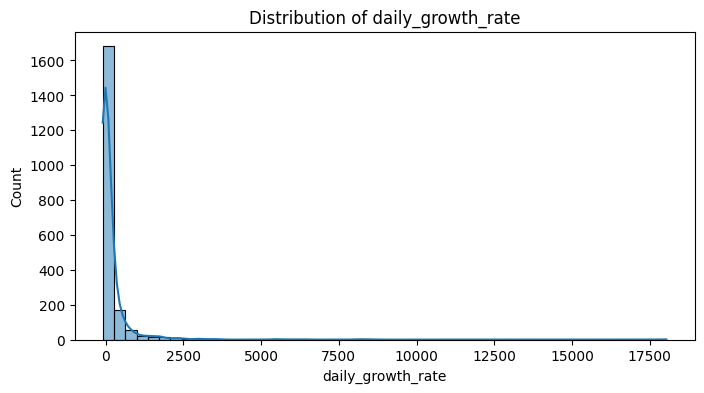

In [3]:
df['views_yesterday'] = df['views'].shift(1)
df['daily_growth_rate'] = ((df['views'] - df['views_yesterday']) / df['views_yesterday']) * 100

# Handle NaN/Inf
df['daily_growth_rate'] = df['daily_growth_rate'].replace([np.inf, -np.inf], np.nan).fillna(0)

plt.figure(figsize=(8,4))
sns.histplot(df['daily_growth_rate'], bins=50, kde=True)
plt.title('Distribution of daily_growth_rate')
plt.show()


## 2. subscriber_net
subscribers_gained - subscribers_lost


In [4]:
print(df.columns)

Index(['Content', 'video_title', 'duration', 'Average view duration',
       'average_percentage_viewed_pct', 'engaged_views', 'Stayed to watch (%)',
       'Average views per viewer', 'Unique viewers', 'New viewers',
       'Returning viewers', 'Casual viewers', 'Regular viewers',
       'Transaction revenue (IDR)', 'Transactions',
       'Revenue per transaction (IDR)', 'youtube_premium_idr',
       'watch_page_ads_idr', 'Estimated DoubleClick revenue (IDR)',
       'estimated_adsense_revenue_idr', 'youtube_ad_revenue_idr',
       'ad_impressions', 'playback_based_cpm_idr', 'cpm_idr',
       'estimated_monetized_playbacks', 'rpm_idr', 'Rubies',
       'YouTube Premium views', 'YouTube Premium watch time (hours)',
       'Playlist watch time (hours)', 'Views from playlist',
       'Views per playlist start', 'Hours streamed', 'Reminders set',
       'Chat messages', 'Reactions', 'Post subscribers', 'Remix count',
       'Remix views', 'Community clip views',
       'Watch time from co

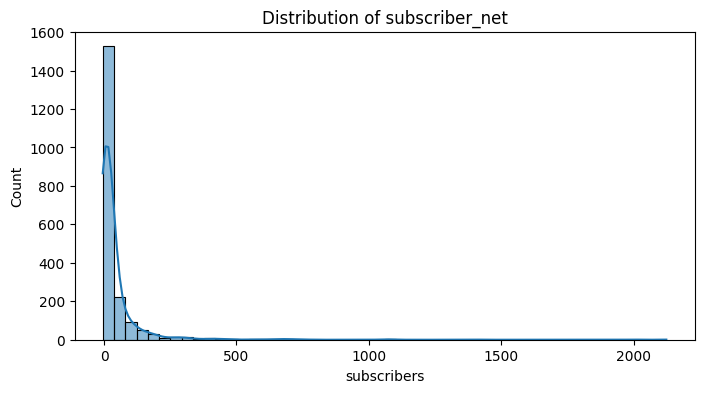

In [5]:
df['subscriber_net'] = df['subscribers'] 

plt.figure(figsize=(8,4))
sns.histplot(df['subscribers'], bins=50, kde=True)
plt.title('Distribution of subscriber_net')
plt.show()


## 3. view_velocity
views / days_since_upload


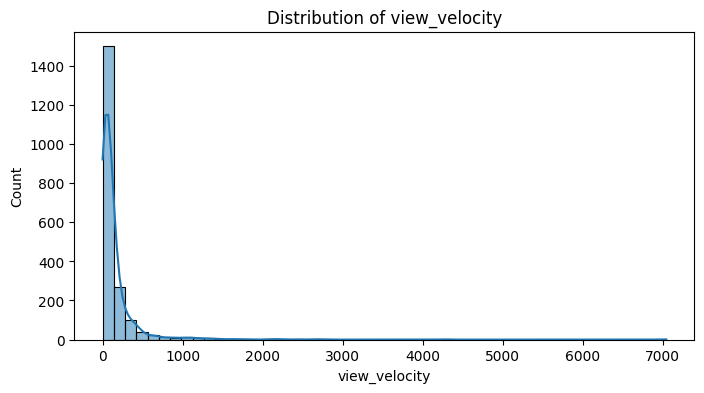

In [6]:
df['days_since_upload'] = (pd.to_datetime('today') - df['publish_date']).dt.days
df['days_since_upload'] = df['days_since_upload'].replace(0, 1) # Avoid division by zero

df['view_velocity'] = df['views'] / df['days_since_upload']

plt.figure(figsize=(8,4))
sns.histplot(df['view_velocity'], bins=50, kde=True)
plt.title('Distribution of view_velocity')
plt.show()


## 4. rolling_avg_views_7d
7-day rolling mean of views


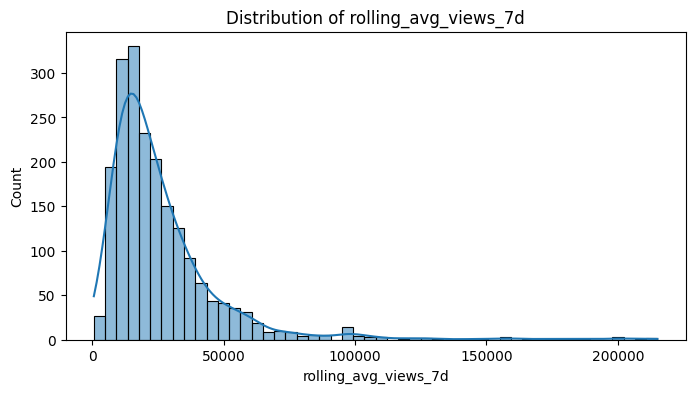

In [7]:
df['rolling_avg_views_7d'] = df['views'].rolling(window=7, min_periods=1).mean()

plt.figure(figsize=(8,4))
sns.histplot(df['rolling_avg_views_7d'], bins=50, kde=True)
plt.title('Distribution of rolling_avg_views_7d')
plt.show()


## 5. growth_acceleration
diff of daily_growth_rate


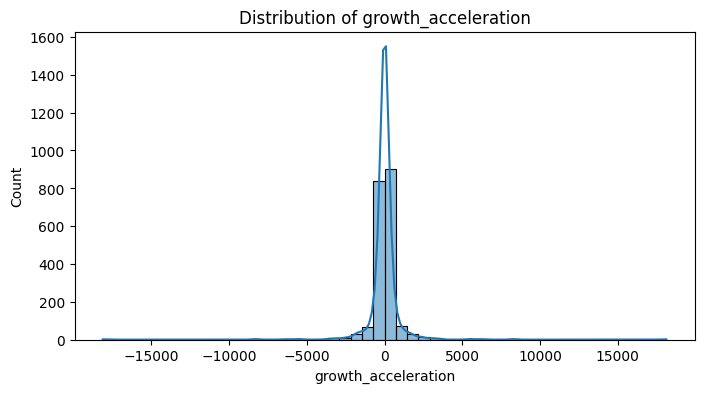

In [8]:
df['growth_acceleration'] = df['daily_growth_rate'].diff().fillna(0)

plt.figure(figsize=(8,4))
sns.histplot(df['growth_acceleration'], bins=50, kde=True)
plt.title('Distribution of growth_acceleration')
plt.show()


## Rolling Average Plot
7-day and 30-day rolling avg views on one line chart.


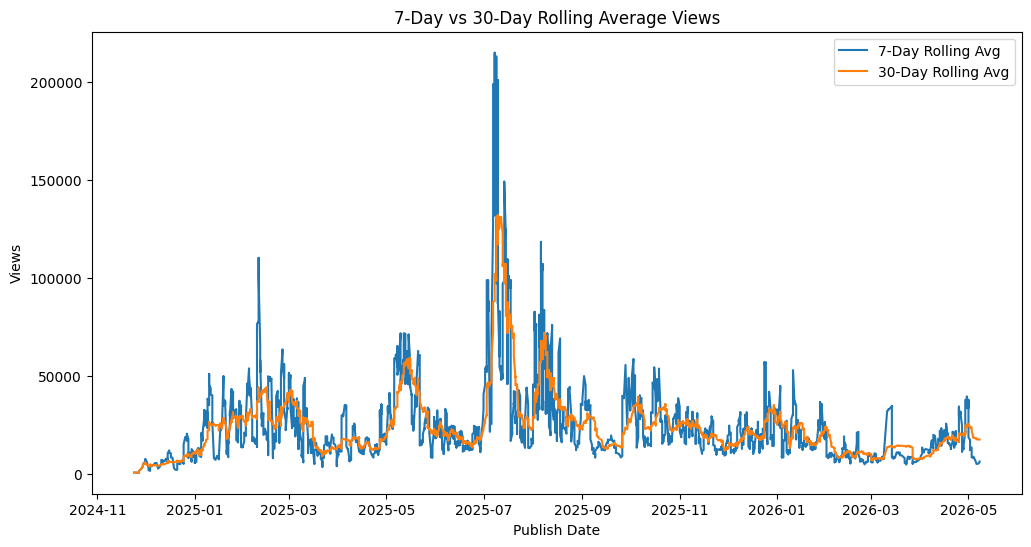

In [9]:
df['rolling_avg_views_30d'] = df['views'].rolling(window=30, min_periods=1).mean()

plt.figure(figsize=(12,6))
plt.plot(df['publish_date'], df['rolling_avg_views_7d'], label='7-Day Rolling Avg')
plt.plot(df['publish_date'], df['rolling_avg_views_30d'], label='30-Day Rolling Avg')
plt.title('7-Day vs 30-Day Rolling Average Views')
plt.xlabel('Publish Date')
plt.ylabel('Views')
plt.legend()
plt.show()


## Save Features


In [10]:
cols_to_save = ['video_id', 'daily_growth_rate', 'subscriber_net', 'view_velocity', 'rolling_avg_views_7d', 'growth_acceleration']
if 'video_id' in df.columns:
    df[cols_to_save].to_csv('../../data/processed/features_growth.csv', index=False)
    print('Saved to features_growth.csv')
else:
    print('video_id not found in dataset')


Saved to features_growth.csv
